In [15]:
import pandas as pd
import numpy as np
import torch
from transformers import BertModel, BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from transformers import Trainer, TrainingArguments
from sklearn.metrics import f1_score

In [2]:
dataset = pd.read_csv('sentiment_data.csv')
dataset = dataset.drop('Unnamed: 0', axis=1)
dataset.head(6)

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2
5,we’ve hounding bank adopt apple pay understand...,1


In [3]:
train_texts, test_texts, train_labels, test_labels = train_test_split(dataset['Comment'], dataset['Sentiment'], test_size= 0.33, random_state=50)

In [4]:
# BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [6]:
train_encodings = tokenizer(
    train_texts.fillna("").astype(str).tolist(),
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts.fillna("").astype(str).tolist(),
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

In [7]:
type(train_encodings)

transformers.tokenization_utils_base.BatchEncoding

In [8]:
class SentimentDataset(torch.utils.data.Dataset):
    
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
        
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item
    
    def __len__(self):
        return len(self.labels)

In [9]:
train_dataset = SentimentDataset(train_encodings, train_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

In [10]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [12]:
training_args = TrainingArguments(
    output_dir="/Volumes/T7/Project/SentimentAnalysis/result",
    per_device_train_batch_size=6,
    per_device_eval_batch_size=6,
    evaluation_strategy="epoch",
    num_train_epochs=2,
    logging_dir="/Volumes/T7/Project/SentimentAnalysis/result/logs"
)

/Users/ayanguin/anaconda3/envs/Python/lib/python3.12/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [14]:
trainer.train()

/Users/ayanguin/anaconda3/envs/Python/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_1060/1293523522.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Epoch,Training Loss,Validation Loss
1,0.534800,0.526132
2,0.458200,0.552684


/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_1060/1293523522.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_1060/1293523522.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_1060/1293523522.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key

TrainOutput(global_step=53856, training_loss=0.5756887148620823, metrics={'train_runtime': 74948.2324, 'train_samples_per_second': 4.311, 'train_steps_per_second': 0.719, 'total_flos': 2.125522278102989e+16, 'train_loss': 0.5756887148620823, 'epoch': 2.0})

In [16]:
predictions = trainer.predict(test_dataset)

/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_1060/1293523522.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


In [17]:
pred_labels = predictions.predictions.argmax(axis=1)

In [24]:
f1 = f1_score(test_labels, pred_labels, average="weighted")

In [34]:
f1

0.8528513336186979

In [29]:
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

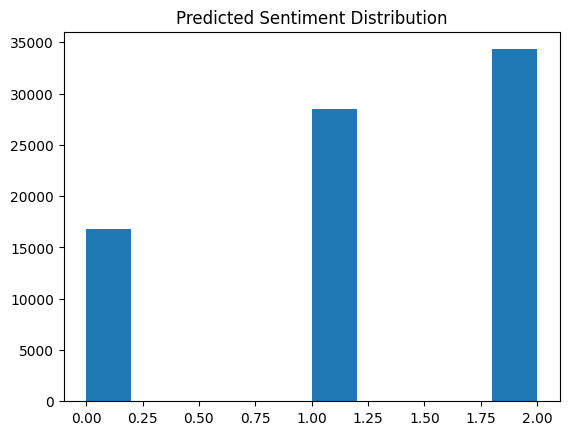

In [30]:
import matplotlib.pyplot as plt

plt.hist(y_pred)
plt.title("Predicted Sentiment Distribution")
plt.show()

In [31]:
print("True labels:", y_true[:10])
print("Pred labels:", y_pred[:10])

True labels: [2 0 1 2 0 2 0 2 2 1]
Pred labels: [2 0 1 2 2 2 0 2 2 1]


In [32]:
f1score = f1_score(y_true, y_pred, average="weighted")
print("F1 Score:", f1score)

F1 Score: 0.8528513336186979


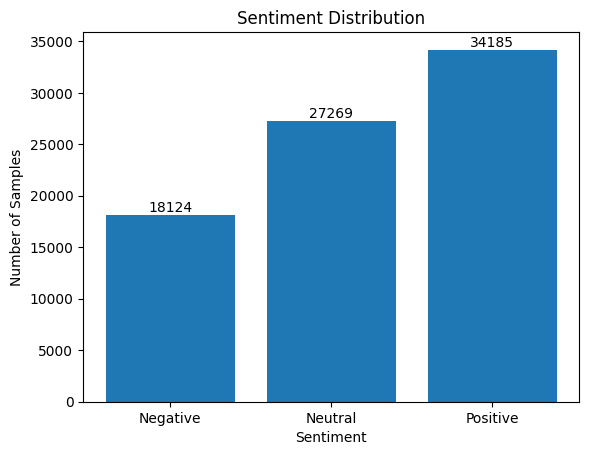

In [83]:
labels = ["Negative", "Neutral", "Positive"]

counts = np.bincount(y_true)

plt.figure()
bars = plt.bar(labels, counts)
plt.bar_label(bars)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")

plt.show()

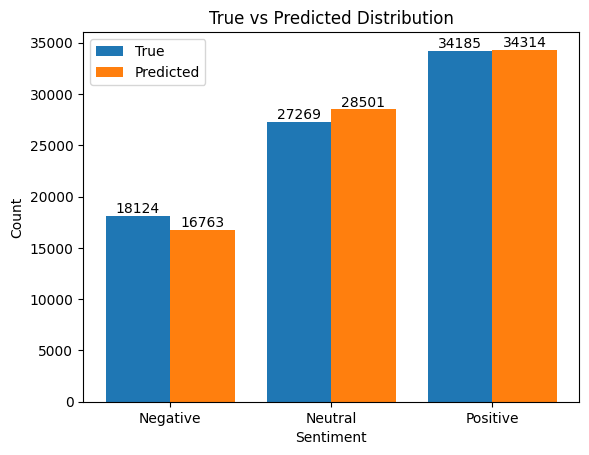

In [ ]:
true_counts = np.bincount(y_true)
pred_counts = np.bincount(y_pred)

x = np.arange(len(labels))

plt.figure()

bars1 = plt.bar(x-0.2, true_counts, width=0.4, label="True")
bars2 = plt.bar(x+0.2, pred_counts, width=0.4, label="Predicted")
plt.bar_label(bars1)
plt.bar_label(bars2)

plt.xticks(x, labels)

plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("True vs Predicted Distribution")

plt.legend()

plt.show()

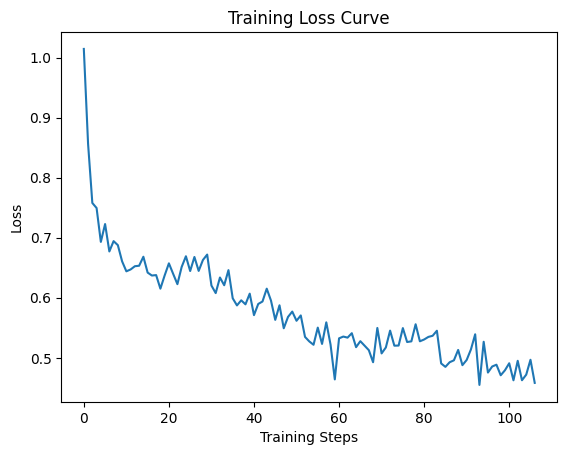

In [37]:
loss_history = trainer.state.log_history

train_loss = [x["loss"] for x in loss_history if "loss" in x]

plt.figure()

plt.plot(train_loss)

plt.title("Training Loss Curve")
plt.xlabel("Training Steps")
plt.ylabel("Loss")

plt.show()

# For User to test the predictions.

In [ ]:
def predict_sentiment(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()

    labels = {
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    }

    return labels[pred]

In [53]:
predict_sentiment("Inquiry regarding room availability – Robert-Schumann-Allee.")

'Neutral'

In [56]:
user_text = input()
print(f"The text is: {user_text}\nThe prediction of the text is: {predict_sentiment(user_text)}")


The text is: I am goood
The prediction of the text is: Positive


In [66]:
predict_sentiment('this 1 is not good')

'Positive'

# Problem with our model and errors.

In [90]:
errors = []

for text, true, pred in zip(test_texts, y_true, y_pred):
    if true != pred:
        errors.append((text, true, pred))


In [69]:
errors[0]

('success mission shakti mean future space tech india',
 np.int64(0),
 np.int64(2))

In [73]:
label_names = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

print("Misclassified examples:")
print("--------------------------------")

for text, true, pred in errors[:5]:   # show first 5 errors
    
    print(f'Text: "{text}"')
    print("True:", label_names[int(true)])
    print("Predicted:", label_names[int(pred)])
    print("--------------------------------")

Misclassified examples:
--------------------------------
Text: "success mission shakti mean future space tech india"
True: Negative
Predicted: Positive
--------------------------------
Text: "i’m mongol favorite comfort food blood enemies"
True: Neutral
Predicted: Positive
--------------------------------
Text: "kindlysend reply big fan modi tamilnadu"
True: Neutral
Predicted: Positive
--------------------------------
Text: "bjp never narrative anything years back ram mandir modi came later rewinding yrs history filled lies bring gandhis damad poor nehru rip pakistan"
True: Neutral
Predicted: Negative
--------------------------------
Text: "opposition concerned abhinandans return iafs valour narendra modi elections news"
True: Positive
Predicted: Neutral
--------------------------------
